# Composite heat fluxes during MHW events
# SPEAR-LO

In [1]:
import xarray as xr
import pandas as pd
import json
import numpy as np
import cmocean
import cartopy.crs as ccrs #cartopy coord ref sys
import cartopy
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap
import time
from tqdm import tqdm
import glob
import os
from collections import defaultdict
import xesmf as xe
import ast #for parsing through events_by_cell.json file

In [12]:
skip_ens = {11, 12, 13, 14, 15}
formatted_list = [str(i).zfill(2) for i in range(1, 31) if i not in skip_ens]

In [13]:
formatted_list

['01',
 '02',
 '03',
 '04',
 '05',
 '06',
 '07',
 '08',
 '09',
 '10',
 '16',
 '17',
 '18',
 '19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30']

In [14]:
def load_hf_ensemble(hf_var, ps, pe):
    """
    Load heat fluxes individually with SPEAR-HI25 ensemble members concatonated into a single ds for each flux
    """
    #formatted_list = [str(i).zfill(2) for i in range(1, 31)]
    skip_ens = {11, 12, 13, 14, 15}
    formatted_list = [str(i).zfill(2) for i in range(1, 31) if i not in skip_ens]
    ds1 = xr.open_mfdataset([f'/work/stb/MHW-gfdl/SPEAR/SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_{ens_num}/{hf_var}_ens{ens_num}_1991-2100.nc' for ens_num in formatted_list], 
                            chunks={}, decode_timedelta=True, concat_dim='ensemble', combine='nested')
    time_period = dict(time=slice(ps, pe))
    ds = ds1.sel(lat=slice(10, 31), lon=slice(262,344), 
                 **time_period).assign_coords(ensemble=[int(e) for e in formatted_list])

    return ds

## SPEAR-HI25 (1991-2024)

Var names to download:
- lwflx
- shflx
- swup_sfc
- swdn_sfc
- evap 

In [30]:
2100-1991

109

In [31]:
110*365

40150

In [32]:
40150-38350

1800

In [15]:
lwflx_9124 = load_hf_ensemble('lwflx', '1991', '2024')


In [16]:
lwflx_9124

<xarray.Dataset> Size: 27GB
Dimensions:     (ensemble: 25, time: 12419, lat: 84, bnds: 2, lon: 263)
Coordinates:
  * ensemble    (ensemble) int64 200B 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30
  * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * lat         (lat) float64 672B 10.12 10.38 10.62 10.88 ... 30.38 30.63 30.88
  * bnds        (bnds) float64 16B 1.0 2.0
  * lon         (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 343.3 343.6 343.9
Data variables:
    average_DT  (ensemble, time) timedelta64[ns] 2MB dask.array<chunksize=(1, 12419), meta=np.ndarray>
    average_T1  (ensemble, time) datetime64[ns] 2MB dask.array<chunksize=(1, 12419), meta=np.ndarray>
    average_T2  (ensemble, time) datetime64[ns] 2MB dask.array<chunksize=(1, 12419), meta=np.ndarray>
    lat_bnds    (ensemble, lat, bnds) float64 34kB dask.array<chunksize=(1, 84, 2), meta=np.ndarray>
    lon_bnds    (ensemble, lon, bnds) float64 105kB dask.array<chunksize=(1, 263, 2), meta=np.ndarray>
    lwflx       (ensemble, time, lat, lon) float32 27GB dask.array<chunksize=(1, 12419, 84, 263), meta=np.ndarray>
    time_bnds   (ensemble, time, bnds) object 5MB dask.array<chunksize=(1, 12419, 2), meta=np.ndarray>
Attributes:
    title:                 SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01
    grid_type:             regular
    grid_tile:             N/A
    code_release_version:  2023.01.02
    git_hash:              8176c2b45079431f2053ec773253938f8aee4828
    creationtime:          Fri May  3 02:26:29 2024
    hostname:              pp338
    history:               Fri Apr 17 12:42:02 2026: ncrcat lwflx_ens01_1991....
    NCO:                   netCDF Operators version 5.2.4 (Homepage = http://...

In [17]:
lwflx_9124.lwflx

<xarray.DataArray 'lwflx' (ensemble: 25, time: 12419, lat: 84, lon: 263)> Size: 27GB
dask.array<getitem, shape=(25, 12419, 84, 263), dtype=float32, chunksize=(1, 12419, 84, 263), chunktype=numpy.ndarray>
Coordinates:
  * ensemble  (ensemble) int64 200B 1 2 3 4 5 6 7 8 ... 23 24 25 26 27 28 29 30
  * time      (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * lat       (lat) float64 672B 10.12 10.38 10.62 10.88 ... 30.38 30.63 30.88
  * lon       (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 343.3 343.6 343.9
Attributes:
    units:          w/m2
    long_name:      net (down-up) longwave flux
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order2

### Open heat fluxes

In [20]:
lwflx_ds = load_hf_ensemble('lwflx')
swdn_sfc = load_hf_ensemble('swdn_sfc')
swup_sfc = load_hf_ensemble('swup_sfc')
swflx_ds = swdn_sfc - swup_sfc
evap_ds = load_hf_ensemble('evap')
shflx_ds = load_hf_ensemble('shflx')
evap_ds

<xarray.Dataset> Size: 161GB
Dimensions:     (ensemble: 30, time: 38350, lat: 124, lon: 282, bnds: 2)
Coordinates:
  * ensemble    (ensemble) int64 240B 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30
  * time        (time) object 307kB 1991-01-01 12:00:00 ... 2100-12-31 12:00:00
  * lat         (lat) float64 992B 0.125 0.375 0.625 0.875 ... 30.38 30.63 30.88
  * lon         (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 349.2 349.5 349.8
  * bnds        (bnds) float64 16B 1.0 2.0
Data variables:
    average_DT  (ensemble, time) timedelta64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    average_T1  (ensemble, time) datetime64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    average_T2  (ensemble, time) datetime64[ns] 9MB dask.array<chunksize=(1, 38350), meta=np.ndarray>
    evap        (ensemble, time, lat, lon) float32 161GB dask.array<chunksize=(1, 38350, 124, 282), meta=np.ndarray>
    lat_bnds    (ensemble, lat, bnds) float64 60kB dask.array<chunksize=(1, 124, 2), meta=np.ndarray>
    lon_bnds    (ensemble, lon, bnds) float64 135kB dask.array<chunksize=(1, 282, 2), meta=np.ndarray>
    time_bnds   (ensemble, time, bnds) object 18MB dask.array<chunksize=(1, 38350, 2), meta=np.ndarray>
Attributes:
    title:                 SPEAR_c384_OM4p25_Hist_SSP245_IC1991_R61_ens_01
    grid_type:             regular
    grid_tile:             N/A
    code_release_version:  2023.01.02
    git_hash:              8176c2b45079431f2053ec773253938f8aee4828
    creationtime:          Fri May  3 02:26:29 2024
    hostname:              pp338
    history:               Thu Apr 16 18:22:59 2026: ncrcat evap_ens01_1991.n...
    NCO:                   netCDF Operators version 5.2.4 (Homepage = http://...

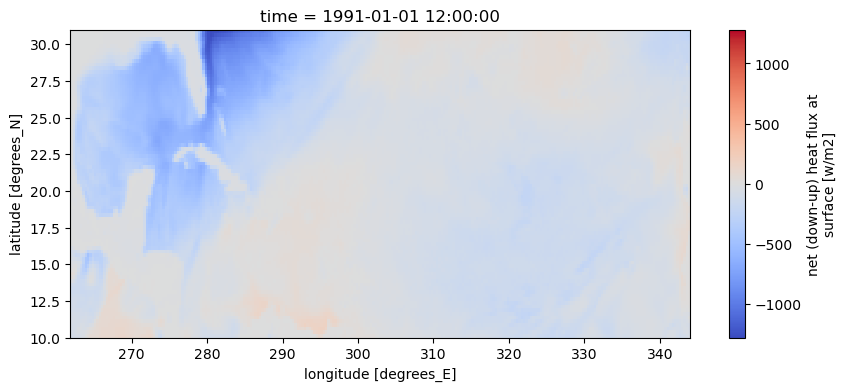

In [17]:
carib[0].plot(figsize=(10,4), cmap='coolwarm')

### Open event masks

In [ ]:
formatted_list = [str(i).zfill(2) for i in range(1, 31) if i not in skip_ens]

In [23]:
skip_ens = {11, 12, 13, 14, 15}
formatted_list = [str(i).zfill(2) for i in range(1,31) if i not in skip_ens]
event_mask9124_lds = [] #list of the ds'
for ens_num in tqdm(formatted_list):
    event_mask9124_lds.append(xr.open_mfdataset(f'/work/stb/MHW-gfdl/SPEAR/vars/SPEAR-HI25/period_1991-2024/events/event_mask_sphi{ens_num}.nc',
                                     decode_timedelta=True).rename_vars({'__xarray_dataarray_variable__': 'event_mask'}))
    time.sleep(0.01)

100%|██████████| 25/25 [00:02<00:00, 12.02it/s]


In [24]:
event_mask9124_lds

[<xarray.Dataset> Size: 364MB
 Dimensions:     (time: 12419, yT: 90, xT: 325)
 Coordinates:
   * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
     month       (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
     dayofyear   (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
   * yT          (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
   * xT          (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
     quantile    float64 8B ...
 Data variables:
     event_mask  (time, yT, xT) bool 363MB dask.array<chunksize=(12419, 90, 325), meta=np.ndarray>,
 <xarray.Dataset> Size: 364MB
 Dimensions:     (time: 12419, yT: 90, xT: 325)
 Coordinates:
   * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
     month       (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
     dayofyear   (time) int64 99kB dask.array<chunksize=(12419,), meta=np.ndarray>
   * yT         

In [25]:
event_mask9124 = xr.concat(event_mask9124_lds, dim='ensemble').drop_vars(('month','dayofyear','quantile'))

In [26]:
event_mask9124

<xarray.Dataset> Size: 9GB
Dimensions:     (ensemble: 25, time: 12419, yT: 90, xT: 325)
Coordinates:
  * time        (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * yT          (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT          (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble
Data variables:
    event_mask  (ensemble, time, yT, xT) bool 9GB dask.array<chunksize=(1, 12419, 90, 325), meta=np.ndarray>

In [27]:
event_mask9124.event_mask

<xarray.DataArray 'event_mask' (ensemble: 25, time: 12419, yT: 90, xT: 325)> Size: 9GB
dask.array<concatenate, shape=(25, 12419, 90, 325), dtype=bool, chunksize=(1, 12419, 90, 325), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 99kB 1991-01-01 12:00:00 ... 2024-12-31 12:00:00
  * yT       (yT) float64 720B 10.2 10.44 10.69 10.93 ... 30.46 30.67 30.89
  * xT       (xT) float64 3kB -97.84 -97.58 -97.33 ... -16.65 -16.4 -16.15
Dimensions without coordinates: ensemble

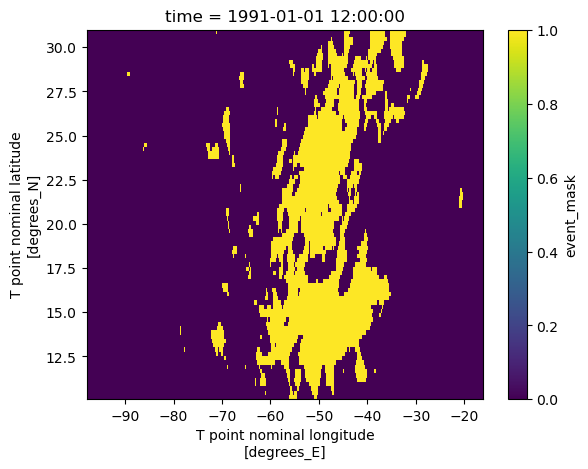

In [76]:
event_mask9124.event_mask.isel(ensemble=0)[0].plot()

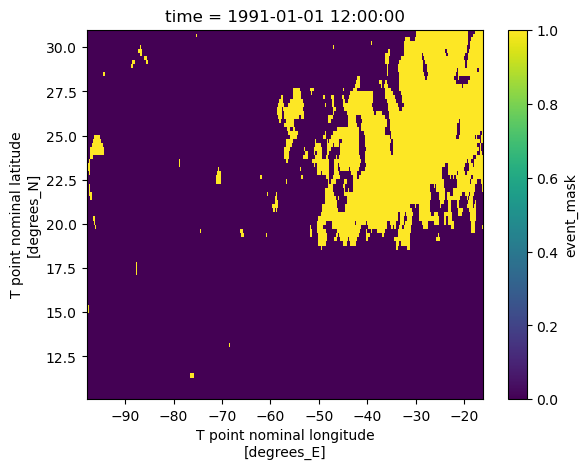

In [77]:
event_mask9124.event_mask.isel(ensemble=1)[0].plot()

In [30]:
# Align the two datasets
flux = lwflx_9124.lwflx
mask = event_mask9124.event_mask
flux, mask = xr.align(flux, mask)
#collect all instances of fluxes when heat events occur
flux_mhws = flux.where(mask)
#"composite" (average) the heat fluxes during mhws
flux_mhw_mean = flux_mhws.mean(dim='time')
#what do the averaged fluxes look like during non-mhw events
flux_nomhw_mean = flux.where(~mask).mean('time')
#Difference of flux magnitude between mhw/non-mhw periods
diff_flux = flux_mhw_mean - flux_nomhw_mean
#What do the anomalous hfs look compared to the climatology?
flux_clim = flux.groupby('time.dayofyear').mean('time')
flux_anom = flux.groupby('time.dayofyear') - flux_clim
flux_mhw_anom = flux_anom.where(mask)
flux_mhw_anom_mean = flux_mhw_anom.mean('time')

In [54]:
flux_rs = flux.resample(time='3YE').mean('time')

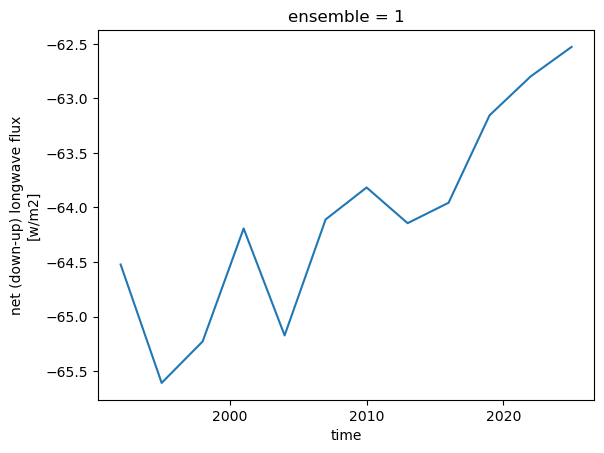

In [55]:
flux_rs.isel(ensemble=0).mean(('lat', 'lon')).plot()

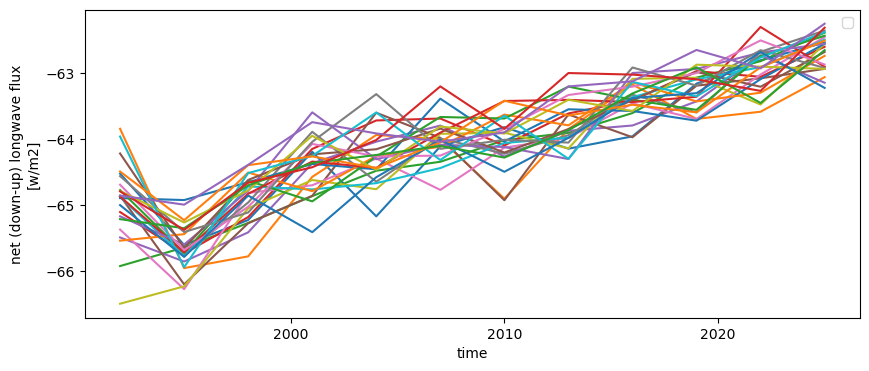

In [61]:
plt.figure(figsize=(10,4))
flux_rs.mean(('lat', 'lon')).plot.line(x="time", hue="ensemble")
plt.legend('');

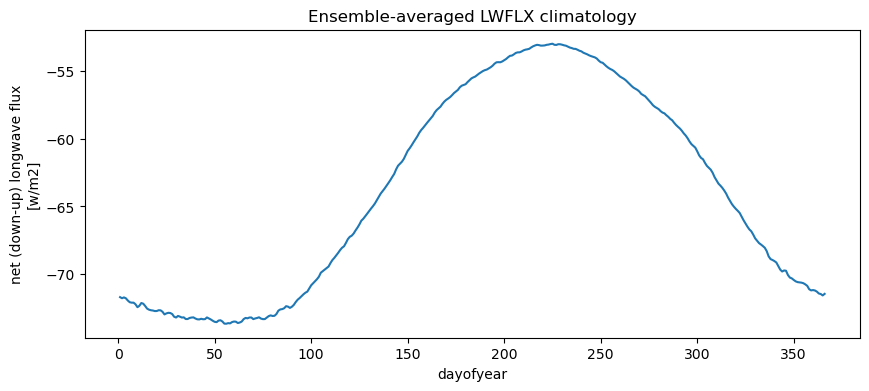

In [65]:
flux_clim.mean(('ensemble', 'lat', 'lon')).plot(figsize=(10,4))
plt.title('Ensemble-averaged LWFLX climatology');

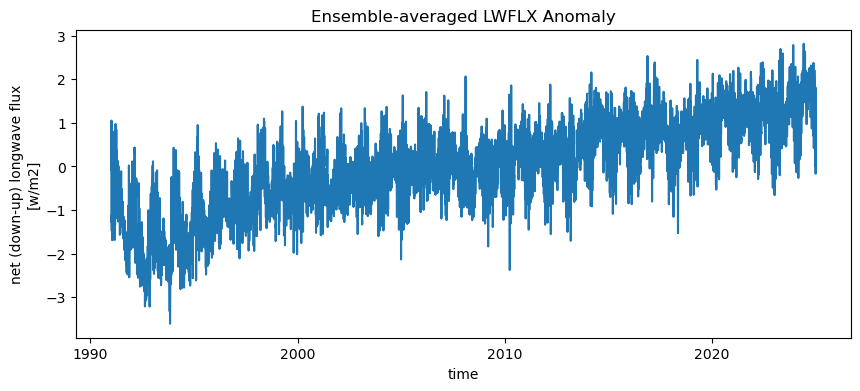

In [66]:
flux_anom.mean(('ensemble', 'lat', 'lon')).plot(figsize=(10,4))
plt.title('Ensemble-averaged LWFLX Anomaly');

In [67]:
flux.mean(('ensemble', 'time'))

<xarray.DataArray 'lwflx' (lat: 84, lon: 263)> Size: 88kB
dask.array<mean_agg-aggregate, shape=(84, 263), dtype=float32, chunksize=(84, 263), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 672B 10.12 10.38 10.62 10.88 ... 30.38 30.63 30.88
  * lon      (lon) float64 2kB 262.0 262.3 262.7 263.0 ... 343.3 343.6 343.9
Attributes:
    units:          w/m2
    long_name:      net (down-up) longwave flux
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT
    interp_method:  conserve_order2

In [68]:
def cartopy_plot_single(da, cmap_choice, cbar_label, var_title, vmin=None, vmax=None, norm=None, quiver=True):
    proj = ccrs.Mercator() #with Mercator you can put lat lon values.
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection=proj))
    ax.set_extent([-98, -60, 17.5, 31], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '50m',
                                            edgecolor='face',
                                            facecolor='0.5'))
    # ---- infer coord names if not provided ----
    lat_candidates = ['lat', 'latitude', 'yT', 'yh']
    lon_candidates = ['lon', 'longitude', 'xT', 'xh']

    lat_name = next((c for c in lat_candidates if c in da.coords), None)
    lon_name = next((c for c in lon_candidates if c in da.coords), None)

    if lat_name is None or lon_name is None:
        raise ValueError(
            f"Could not infer lat/lon coordinates. "
            f"Found coords: {list(da.coords)}"
        )

    lats = da[lat_name]
    lons = da[lon_name]

    # ---- normalization logic ----
    if norm is None:
        # simple linear scaling
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    else:
        # override norm limits if vmin/vmax are supplied
        if vmin is not None:
            norm.vmin = vmin
        if vmax is not None:
            norm.vmax = vmax
    # -------------------------------------------------------------------------------
    im = ax.pcolormesh(lons, lats, da, transform=ccrs.PlateCarree(), 
                       norm=norm, cmap=cmap_choice)
    cb = fig.colorbar(im, ax=ax, shrink=0.25, pad=0.1)
    cb.set_label(fr"{cbar_label}", labelpad=8, fontsize=12)
    g1 = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True)
    g1.xlabels_top = False
    g1.ylabels_right = False
    plt.title(f'{var_title}', fontsize=14, y=1.09)

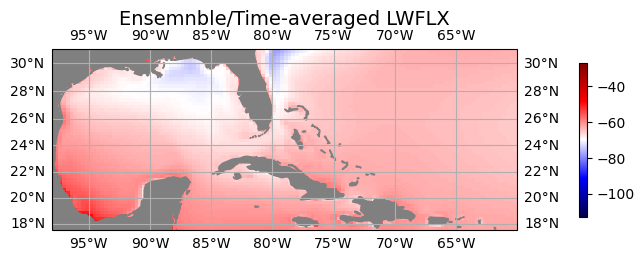

In [69]:
cartopy_plot_single(flux.mean(('ensemble', 'time')), 'seismic', '', r'Ensemnble/Time-averaged LWFLX');

In [ ]:
#What does the total surface forcing look like during MHWs in a warming climate?

In [ ]:
#What physical processes drive MHWs relative to local variability
flux_anom = flux.groupby('time.dayofyear') - flux_clim #detrending
flux_mhw = flux_anom.where(event_mask)
composite = flux_mhw.mean('time')

In [ ]:
#remove seasonal cycle
flux_clim = flux.groupby('time.month').mean('time')
flux_anom = flux.groupby('time.month') - flux_clim
#Detrend anomaly
p = flux_anom.polyfit(dim='time', deg=1)
fit = xr.polyval(flux_anom.time, p.polyfit_coefficients)

flux_detrended = flux_anom - fit
flux_detrended_anom.where(event_mask)

- weak flux anomalies during MHWs (and strong SST anomalies) suggests ocean memory / subsurface processes

- strong positive net heat flux suggests atmospheric forcing

In [31]:
def nrmse_std_norm(model, obs):
    """
    nRMSE normalized by spatial standard deviation of observations
    """
    rmse = np.sqrt(((model - obs) ** 2).mean())
    norm = obs.std()
    return rmse / norm

In [29]:
med_dur_200m = median_duration_ens_mean.where(mask)
freq_200m = frequency_ens_mean.drop_vars(('quantile','dayofyear','month', 'time')).where(mask)
int_200m = intensity_ens_mean.drop_vars('quantile').where(mask)

In [34]:
nrmse_freq_oi = nrmse_std_norm(freq_200m, freqo.where(mask)).values
nrmse_duration_oi = nrmse_std_norm(med_dur_200m, duro.where(mask)).values
nrmse_intensity_oi = nrmse_std_norm(int_200m, into.where(mask)).values

nrmse_freq_era = nrmse_std_norm(freq_200m, freqe.where(mask)).values
nrmse_duration_era = nrmse_std_norm(med_dur_200m, dure.where(mask)).values
nrmse_intensity_era = nrmse_std_norm(int_200m, inte.where(mask)).values

#nrmse_freq_oe = nrmse_std_norm(event_count_yearly_era.mean('time'), freq_ng_oe).values
#nrmse_duration_oe = nrmse_std_norm(median_duration_per_cell_era, med_dur_ng_oe).values
#nrmse_intensity_oe = nrmse_std_norm(mhw_intensity_yearly_era.mean('time'), int_ng_oe).values

In [38]:
nrmse_freq_oi

array(1.37157446)

In [39]:
nrmse_duration_oi

array(4.47572848)

In [40]:
nrmse_intensity_oi

array(1.00564824)

<p style="text-align: center;">nRMSE at 200m bathymetry</p>

| $\overline{S} - O$ | Freq | Duration | Intensity |
| --------- | -------| -------|  -------|
| OISST | 1.37 | 4.48 | 1.01 |
| ERA5 | 1.08 | 2.74 | 0.99 |
| ERA5/OISST | ? | ? | ? |

| nRMSE     | Meaning                                                         |
| --------- | --------------------------------------------------------------- |
| **< 0.5** | Model errors are small relative to observed spatial variability |
| **~ 1.0** | Model error equals typical observed spatial spread              |
| **1–2**   | Model errors large relative to real-world variability           |
| **> 2**   | Model performs poorly for this metric                           |
